In [36]:
import pandas as pd 

In [37]:
import os
import pandas as pd 
df=pd.read_csv("C:/Users/JAYARAM/Desktop/TrafficIQ/data/raw/traffic_dataset.csv")
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='str')

In [38]:
df["DateTime"]=pd.to_datetime(df["DateTime"])
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [39]:
df["Year"]=df["DateTime"].dt.year
df["Month"]=df["DateTime"].dt.month
df["Day"]=df["DateTime"].dt.day
df["Hour"]=df["DateTime"].dt.hour
df["Dayofweek"]=df["DateTime"].dt.day_of_week

In [40]:
df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,Dayofweek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6


In [41]:
df.isnull().sum()

DateTime     0
Junction     0
Vehicles     0
ID           0
Year         0
Month        0
Day          0
Hour         0
Dayofweek    0
dtype: int64

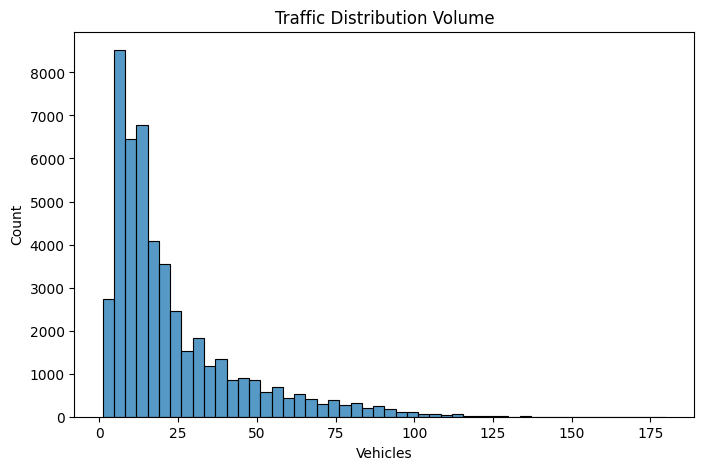

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Vehicles"],bins=50)
plt.title("Traffic Distribution Volume")
plt.show()

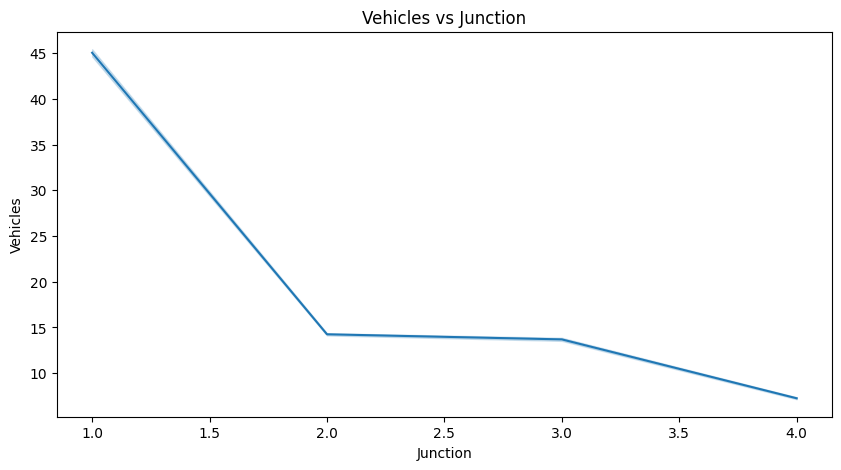

In [43]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Junction",y="Vehicles",data=df)
plt.title("Vehicles vs Junction")
plt.show()

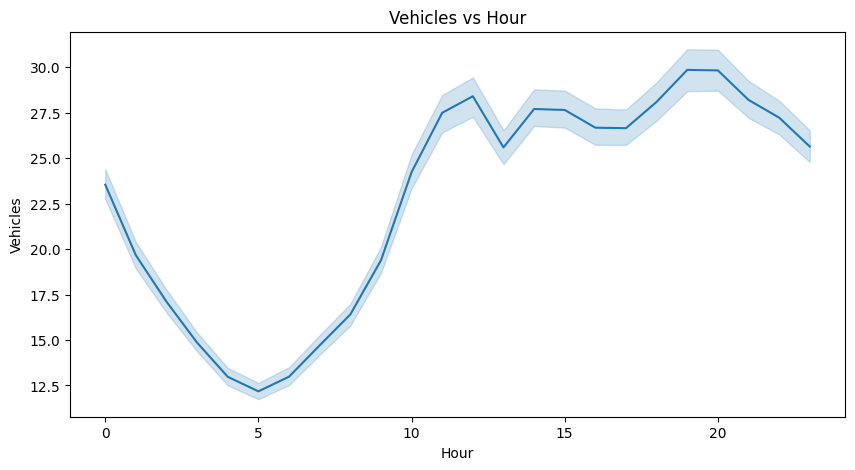

In [44]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Hour",y="Vehicles",data=df)
plt.title("Vehicles vs Hour")
plt.show()

<Axes: xlabel='Hour', ylabel='Vehicles'>

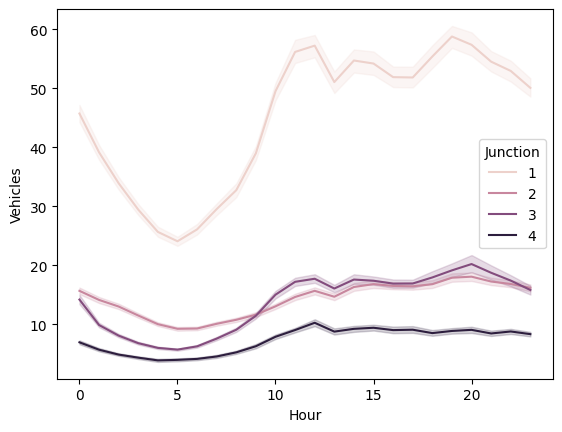

In [45]:
sns.lineplot(x="Hour", y="Vehicles", hue="Junction", data=df)

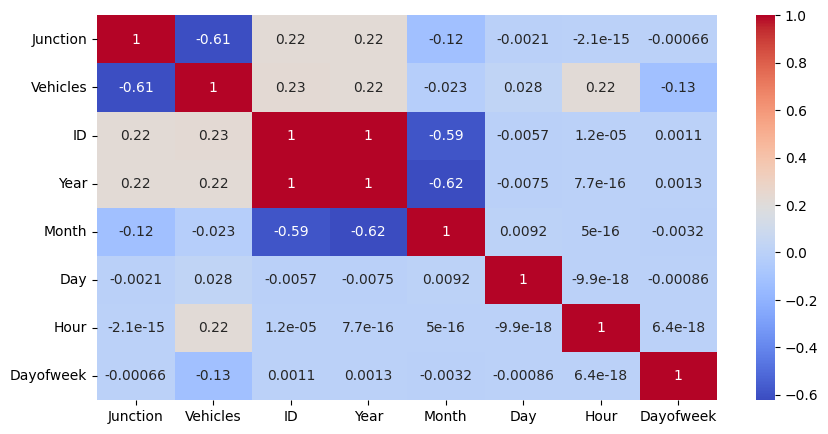

In [46]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [47]:
df['Year'].unique()

array([2015, 2016, 2017], dtype=int32)

In [48]:
df=df.drop(columns=["ID","DateTime"],errors="ignore")
df.columns

Index(['Junction', 'Vehicles', 'Year', 'Month', 'Day', 'Hour', 'Dayofweek'], dtype='str')

In [49]:
df.head()

,Junction,Vehicles,Year,Month,Day,Hour,Dayofweek
0,1,15,2015,11,1,0,6
1,1,13,2015,11,1,1,6
2,1,10,2015,11,1,2,6
3,1,7,2015,11,1,3,6
4,1,9,2015,11,1,4,6


In [57]:
df.to_csv("C:/Users/JAYARAM/Desktop/TrafficIQ/data/processed/processed_traffic_dataset.csv",index=False)

In [54]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from ml_model.preprocessing import get_data

X_train, X_test, y_train, y_test = get_data()

In [56]:
print(X_train.shape)
print(X_test.shape)

(38496, 7)
(9624, 7)


In [2]:
import sqlite3

conn = sqlite3.connect("traffic.db")
cursor = conn.cursor()

with open("C:/Users/JAYARAM/Desktop/TrafficIQ/database/traffic_schema.sql") as f:
    cursor.executescript(f.read())

conn.commit()
conn.close()

print("Database created successfully")


Database created successfully
